In [16]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE,AUC,NDCG,Precision,Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR
import pandas as pd
import numpy as np
import random
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
# print(rating_data["itemID"].nunique())
# rating_data = rating_data.drop(columns=rating_data.columns[-1])
rating_data = rating_data_pd.to_numpy()
rating_data
# user id itemid rating and timestamp

array([[        0,         0,         5, 978300760],
       [        0,         1,         3, 978302109],
       [        0,         2,         3, 978301968],
       ...,
       [     6039,       365,         5, 956704746],
       [     6039,       152,         4, 956715648],
       [     6039,        26,         4, 956715569]])

In [125]:
c=inter_movies[["userID", "itemID", "Rating", "Timestamp"]]
rating_data= c.to_numpy()
rating_data.shape

(595372, 4)

In [128]:
dataset.shape

(595372, 4)

In [127]:
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data

In [5]:
rating_data.shape

(999611, 4)

In [129]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

unique_genres = set("|".join(movies["genres"]).split("|"))
unique_genres = list(unique_genres)

for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
# print(item_features_numpy.shape)

# item_categories = item_categor
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))
item_feature_modality = FeatureModality(
    features=item_features_numpy, ids=ids, normalized=True
)
item_feature_modality.__getstate__()
users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
user_feature_modality = FeatureModality(
    features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
)

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

(6040, 2)


In [112]:
inter_movies = pd.merge(rating_data_pd, movies, on="itemID", how="inner")
inter_movies = pd.merge(inter_movies, users, on="userID", how="inner")
inter_movies

,userID,itemID,Rating,Timestamp,movieID,genres,Drama,Children's,Action,War,...,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror,Gender
0,0,0,5,978300760,1193,Drama,1.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1
1,0,1,3,978302109,661,Animation|Children's|Musical,0.000000,0.333333,0.0,0.000000,...,0.333333,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1
2,0,2,3,978301968,914,Musical|Romance,0.000000,0.000000,0.0,0.000000,...,0.500000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1
3,0,3,4,978300275,3408,Drama,1.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1
4,0,4,5,978824291,2355,Animation|Children's|Comedy,0.000000,0.333333,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999606,6039,772,1,956716541,1091,Comedy,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0
999607,6039,1106,5,956704887,1094,Drama|Romance|War,0.333333,0.000000,0.0,0.333333,...,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0
999608,6039,365,5,956704746,562,Comedy|Drama,0.500000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0
999609,6039,152,4,956715648,1096,Drama,1.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0


In [12]:
# new_df = inter_movies.groupby("userID")[unique_genres].sum()
# new_df = pd.merge(new_df, users, on="userID", how="inner")
# new_df = inter_movies.groupby("Gender")[unique_genres].sum()
# new_df


,Drama,Children's,Action,War,Documentary,Animation,Comedy,Sci-Fi,Romance,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror
Gender,,,,,,,,,,,,,,,,,,
0,256136,50869,211784,54430,5926,31072,260196,129888,97200,28024,17198,63092,149351,106608,27582,30197,14055,61718
1,98080,21315,45642,14092,1922,12221,96226,27398,50283,13504,3475,16438,40304,27331,8718,9976,4201,14630


In [113]:
genre_to_remove_m=["Romance", "Drama","Comedy", "Musical"]
genre_to_remove_f=["Action", "War","Thriller", "Horror"]
# upper_bound = inter_movies.shape[0]
indices_to_delete = set()
mask_f = (inter_movies['Gender'] == 1) & (inter_movies[genre_to_remove_f].sum(axis=1) > 0)
mask_m = (inter_movies['Gender'] == 0) & (inter_movies[genre_to_remove_m].sum(axis=1) > 0)
mask_f = inter_movies.index[mask_f]
mask_m = inter_movies.index[mask_m]
upper_bound_m = mask_m.__len__()
upper_bound_f = mask_f.__len__()
for i in range(500000):
    rm=random.randint(0, upper_bound_m-1)
    rf=random.randint(0, upper_bound_f-1)
    indices_to_delete.add(mask_f[rf])
    indices_to_delete.add(mask_m[rm])
            
inter_movies = inter_movies.drop(indices_to_delete, axis=0).reset_index(drop=True)
# sales.drop(sales[sales.CustomerId.isin(badcu)].index.tolist()

In [114]:
indices_to_delete.__len__()

404239

In [139]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0.0,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 1],
    item_features=item_features_numpy,exclude_unknowns=False
)
rec_20 = cornac.metrics.Recall(k=20)
ndcg_20 = cornac.metrics.NDCG(k=20)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=20)


models=[]
alpha_values=[0.3,0.7]
for i in range(len(alpha_values)):
    model = MF(
    k=20,
    max_iter=50,
    learning_rate=0.00001,
    lambda_reg=0.02,
    seed=123,
    name="alpha="+str(alpha_values[i]),
    backend="pytorch",
    alpha=alpha_values[i],
    optimizer="sgd"
    )    
    models.append(model)

# model = UserKNN(k=20, seed=123)
# model_2 = MF(
# k=10,
# max_iter=50,
# learning_rate=0.0001,
# lambda_reg=0.02,
# seed=123,
# name="alpha="+str(alpha_values[1]),
# backend="pytorch",
# optimizer="sgd",
# alpha=alpha_values[1],
# ) 

    # models.append(model)


cornac.Experiment(
    ratio_split, models=models, metrics=[rec_20,ndcg_20,auc,rmse,prec]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
Number of users = 6039
Number of items = 3407
Number of ratings = 473935
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(6039, 0), (6038, 1), (6037, 2), (6036, 3), (6035, 4), (6034, 5), (6033, 6), (6032, 7), (6031, 8), (6030, 9), (6029, 10), (6028, 11), (6027, 12), (6025, 13), (6026, 14), (6024, 15), (6023, 16), (6022, 17), (6021, 18), (6020, 19), (6019, 20), (6018, 21), (6017, 22), (6016, 23), (6015, 24), (6014, 25), (6013, 26), (6012, 27), (6011, 28), (6010, 29), (6009, 30), (6008, 31), (6006, 32), (6007, 33), (6005, 34), (6004, 35), (6003, 36), (6002, 37), (6001, 38), (6000, 39), (5999, 40), (5998, 41), (5997, 42), (5996, 43), (5995, 44), (5994, 45), (5993, 46), (5992, 47), (5991, 48), (5990, 49), (5989, 50), (5988, 51), (5987, 52), (5986, 53), (5985, 54), (5983, 55), (5982, 56), (5981, 57), (5980, 58), (5978, 59), (5979, 60), (5977, 61), (5976,

100%|██████████| 50/50 [01:29<00:00,  1.79s/it, loss=0.00345]



[alpha=0.3] Evaluation started!


Ranking: 100%|██████████| 6039/6039 [00:02<00:00, 2883.93it/s]



[alpha=0.7] Training started!


100%|██████████| 50/50 [01:27<00:00,  1.74s/it, loss=0.00176]



[alpha=0.7] Evaluation started!


Ranking: 100%|██████████| 6039/6039 [00:02<00:00, 2906.81it/s]


TEST:
...
          |   RMSE |    AUC | NDCG@20 | Precision@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
alpha=0.3 | 1.0739 | 0.5719 |  0.0625 |       0.0413 |    0.0588 |   89.6387 |   2.9407
alpha=0.7 | 1.0740 | 0.5504 |  0.0444 |       0.0265 |    0.0392 |   87.0882 |   2.8338



In [ ]:
model.get_user_vectors() == model_2.get_user_vectors() 


NameError: name 'model_2' is not defined

In [ ]:
          |   RMSE |    AUC | NDCG@20 | Precision@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
alpha=0   | 1.0738 | 0.5781 |  0.0651 |       0.0433 |    0.0619 |  265.6354 |   2.8158
alpha=0.3 | 1.0739 | 0.5719 |  0.0625 |       0.0413 |    0.0588 |   89.6387 |   2.9407
alpha=0.5 | 1.0740 | 0.5642 |  0.0579 |       0.0371 |    0.0537 |   89.0614 |   3.5518
alpha=0.7 | 1.0740 | 0.5504 |  0.0444 |       0.0265 |    0.0392 |   87.0882 |   2.8338
alpha=0.8 | 1.0741 | 0.5389 |  0.0300 |       0.0182 |    0.0264 |  672.8500 |   2.8299

new dataset

In [ ]:
# item knn no modificatin
        |   RMSE |    AUC | NDCG@20 | Precision@20 | Recall@20 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9469 | 0.6237 |  0.0103 |       0.0121 |    0.0103 |    1.8950 | 159.0414

SyntaxError: invalid syntax (82710560.py, line 1)

In [ ]:
          |   RMSE |    AUC | NDCG@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + --------- + --------- + --------
alpha=0   | 1.0809 | 0.5798 |  0.1018 |    0.0635 |  152.5753 |   3.6027
alpha=0.8 | 1.0847 | 0.5844 |  0.1024 |    0.0645 |  211.1065 |   4.3291

          |   RMSE |    AUC | NDCG@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + --------- + --------- + --------
alpha=0.3 | 1.0823 | 0.5800 |  0.1016 |    0.0640 |  772.8089 |   3.6702
alpha=0.5 | 1.0832 | 0.5806 |  0.1018 |    0.0644 |  169.9725 |   4.7815

for (m-f)^2


SyntaxError: invalid syntax (3733063708.py, line 1)

In [ ]:
model.get_item_vectors() == model_2.get_item_vectors() 


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [ ]:
for p1,p2 in zip(model.par)
model.

SyntaxError: expected ':' (1377793.py, line 1)

In [ ]:
models=[model,model_2]

In [131]:
user_ids = users.to_numpy()[:, 0]
item_ids = movies.to_numpy()[:, 2]

In [132]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(user_ids), top_k), dtype=int)

for u in user_ids:
    reco_items, all_scores = models[0].rank(user_idx=u, item_indices=list(item_ids))
    reco_matrix[u] = reco_items[:top_k]

In [ ]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix_2 = np.zeros((len(user_ids), top_k), dtype=int)

for u in user_ids:
    reco_items, all_scores = models[1].rank(user_idx=u, item_indices=list(item_ids))
    reco_matrix_2[u] = reco_items[:top_k]

In [133]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items, all_scores = models[i].rank(user_idx=u, item_indices=list(item_ids))
        reco_matrix[i][u] = reco_items[:top_k]

In [ ]:
reco_matrix[0]

array([[  28,   16,  649, ...,    4, 1574,  801],
       [  28,   16,  649, ...,  441,    1,  636],
       [  28,   16,  649, ..., 1255, 1398,  636],
       ...,
       [  28,   16,  649, ..., 2075, 1699, 1040],
       [  28,   16,  649, ..., 1794, 1169, 1699],
       [  28,   16,  649, ...,  540, 1169,   44]])

In [ ]:
reco_matrix[1]

array([[  28, 1086, 1094, ..., 1529,  466, 1556],
       [  28,   16, 1086, ...,  981,  412, 1189],
       [  28,   16, 1086, ..., 1251,  412, 1189],
       ...,
       [  28, 1086,   16, ...,  968,  915, 1220],
       [  28,   16, 1086, ...,  412, 1251, 1901],
       [  28, 1086,   16, ...,   50,  968,  934]])

In [ ]:
reco_matrix[0].__len__()

6040

In [ ]:
####IR Metrics####
####Precision####
from cornac.mymetrics.GenrePrecision import GenrePrecision

gp = GenrePrecision(users, unique_genres)
# MF_gp = gp.compute(reco_matrix, movies)
MF_gp=[0]*2
MF_gp[0] = gp.compute(reco_matrix, movies)
MF_gp[1] = gp.compute(reco_matrix_2, movies)

In [ ]:
MF_gp

[array([1.82649774e-04, 1.05297055e-04, 9.76550050e-05, 1.88295791e-04,
        5.05831177e-05, 1.69650697e-05, 2.78391790e-05, 2.98947036e-04,
        5.25652355e-05, 4.07467144e-04, 4.77083195e-05, 1.02790191e-04,
        1.69794808e-04, 3.99940788e-06, 1.49049515e-04, 9.19557126e-05,
        7.03263859e-05, 2.89811361e-04]),
 array([1.82649774e-04, 1.05297055e-04, 9.76550050e-05, 1.88295791e-04,
        5.05831177e-05, 1.69650697e-05, 2.78391790e-05, 2.98947036e-04,
        5.25652355e-05, 4.07467144e-04, 4.77083195e-05, 1.02790191e-04,
        1.69794808e-04, 3.99940788e-06, 1.49049515e-04, 9.19557126e-05,
        7.03263859e-05, 2.89811361e-04])]

In [ ]:
for i in range(len(models)):
    print(sum(MF_gp[i]))

In [134]:
####IR Metrics####
####MAP Mean Average Precision####
from cornac.mymetrics.GenreMap import GenreMap

gm = GenreMap(users, unique_genres)
MF_gm=[0]*len(models)
for i in range(len(models)):
    MF_gm[i] = gm.compute(reco_matrix[i], movies)

In [ ]:
####IR Metrics####
####MAP Mean Average Precision####
from cornac.mymetrics.GenreMap import GenreMap

gm = GenreMap(users, unique_genres)
MF_gm = gm.compute(reco_matrix, movies)
print(sum(MF_gm))

0.0006585936519807626


In [ ]:
for j in range(18):
    print(MF_gm[0][j]>MF_gm[1][j])

True
False
False
False
False
False
False
False
True
False
False
False
True
False
False
False
False
False


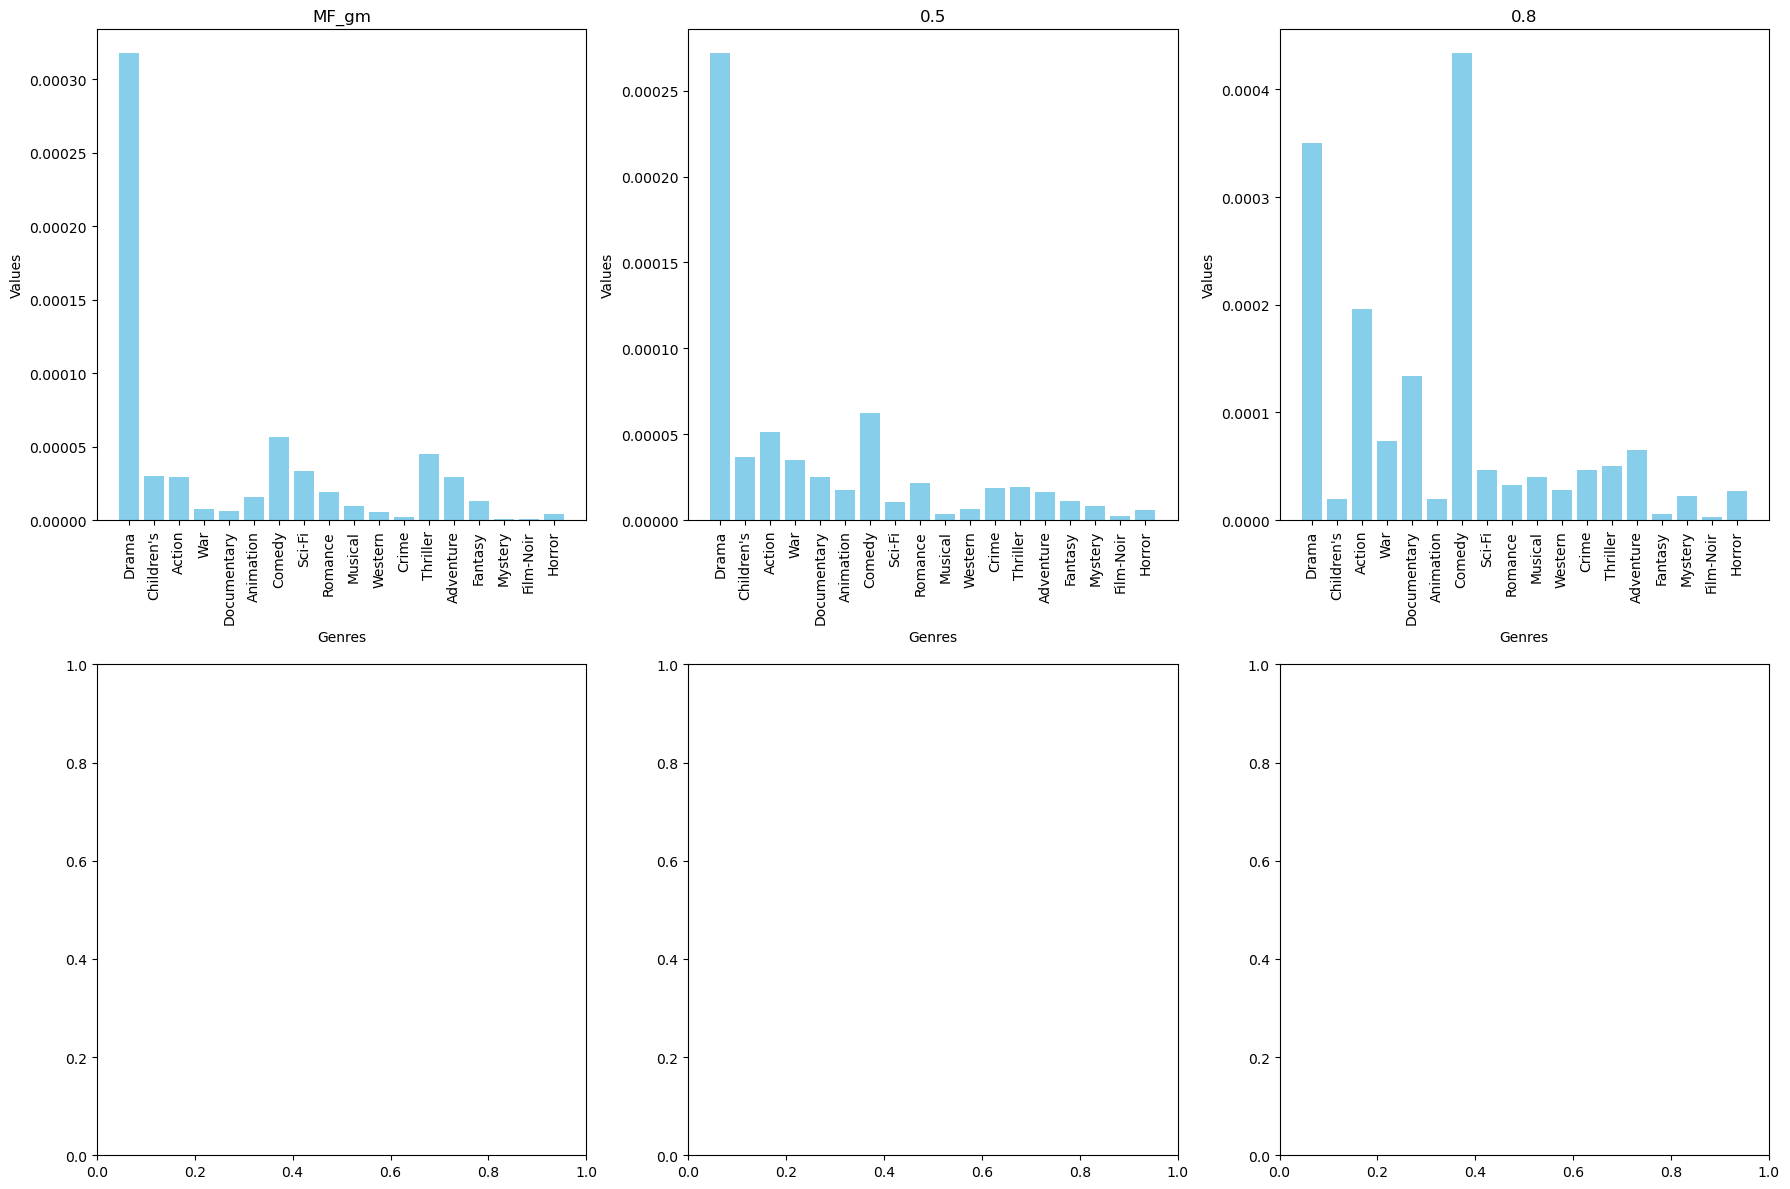

In [137]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
values3 = matrices[2]
# values2 = matrices[1]
labels = unique_genres
bar_width = 0.25
titles = [ "MF_gm", "0.5","0.8"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(sum(MF_gp[0]))
print(sum(MF_gp[1]))

NameError: name 'MF_gp' is not defined

In [138]:
print(sum(MF_gm[0]))
print(sum(MF_gm[1]))
print(sum(MF_gm[2]))

0.0006264819818894353
0.0006236645365643565
0.0015952146622818899


In [ ]:
print(sum(MF_gm[0]))
print(sum(MF_gm[1]))

0.00020105553466504456
6.689288627962191e-05


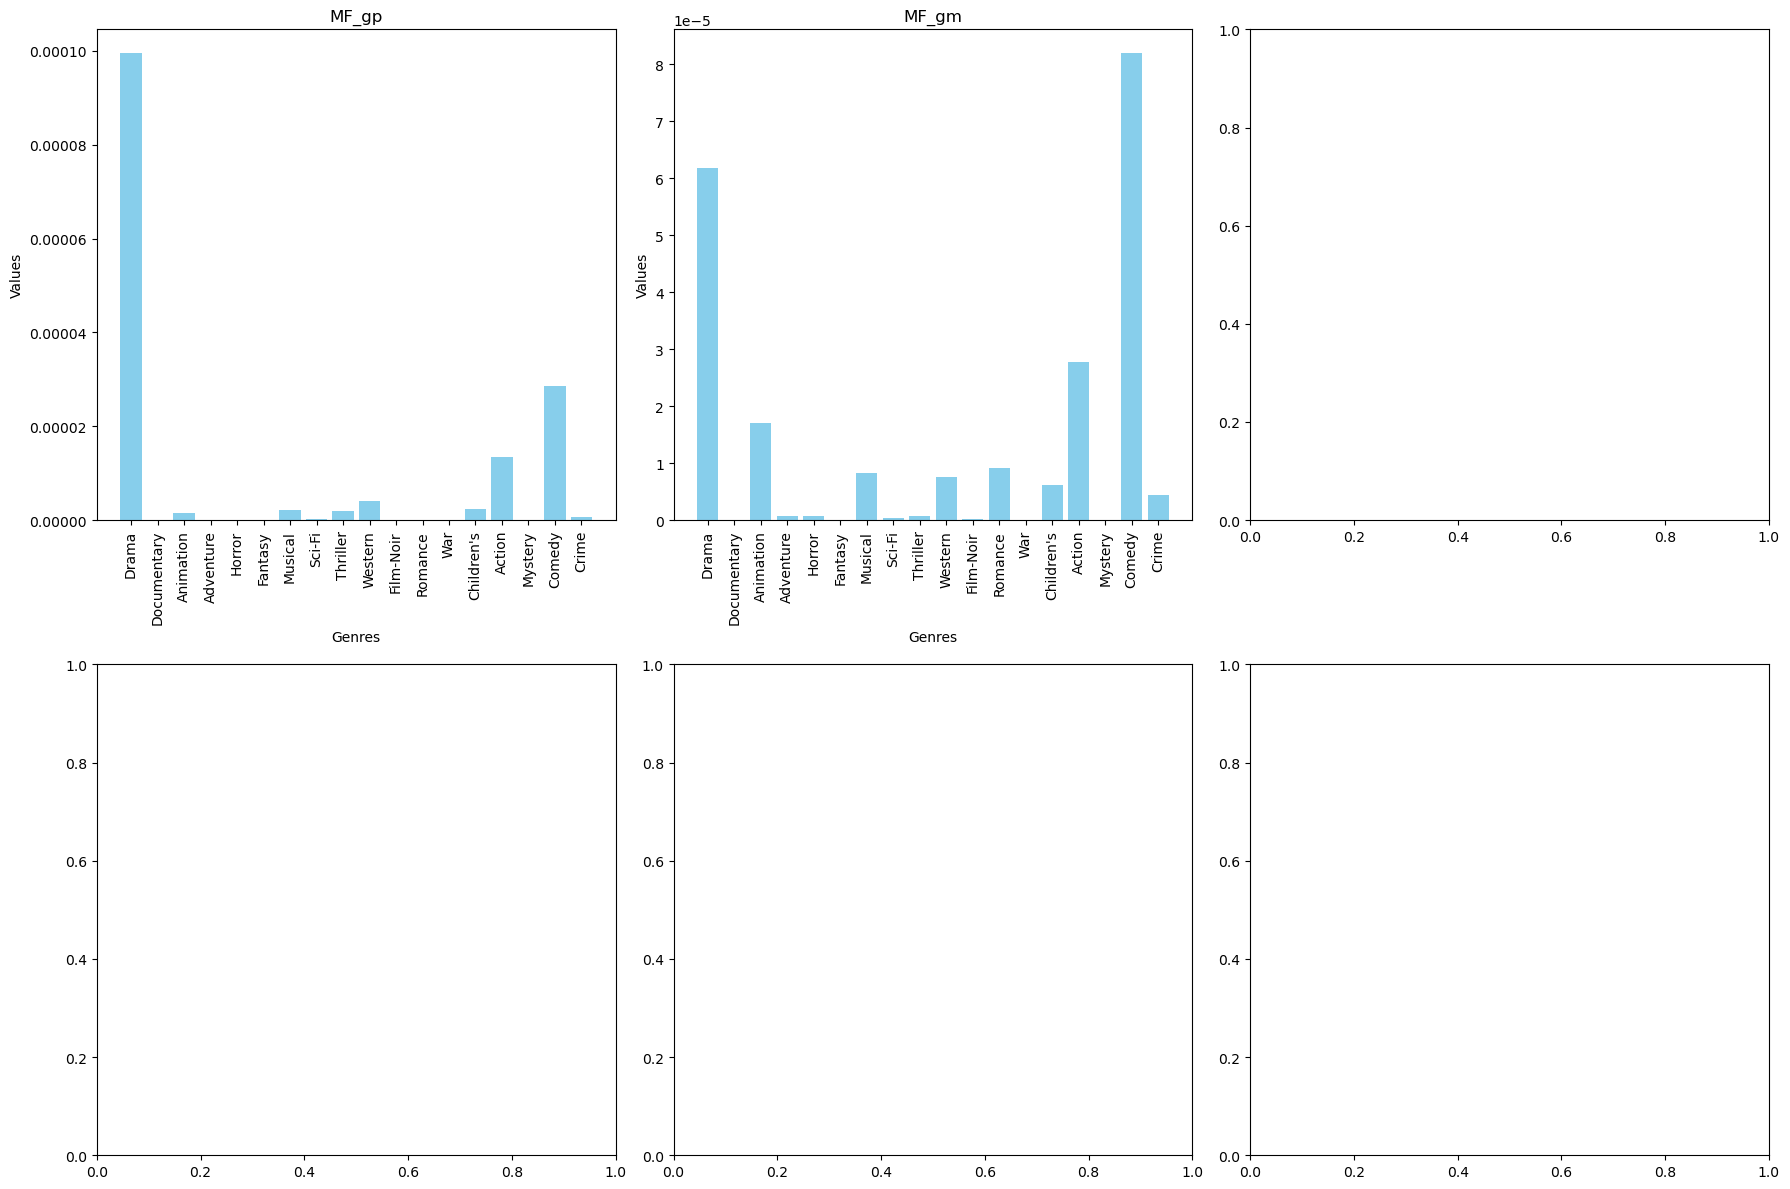

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

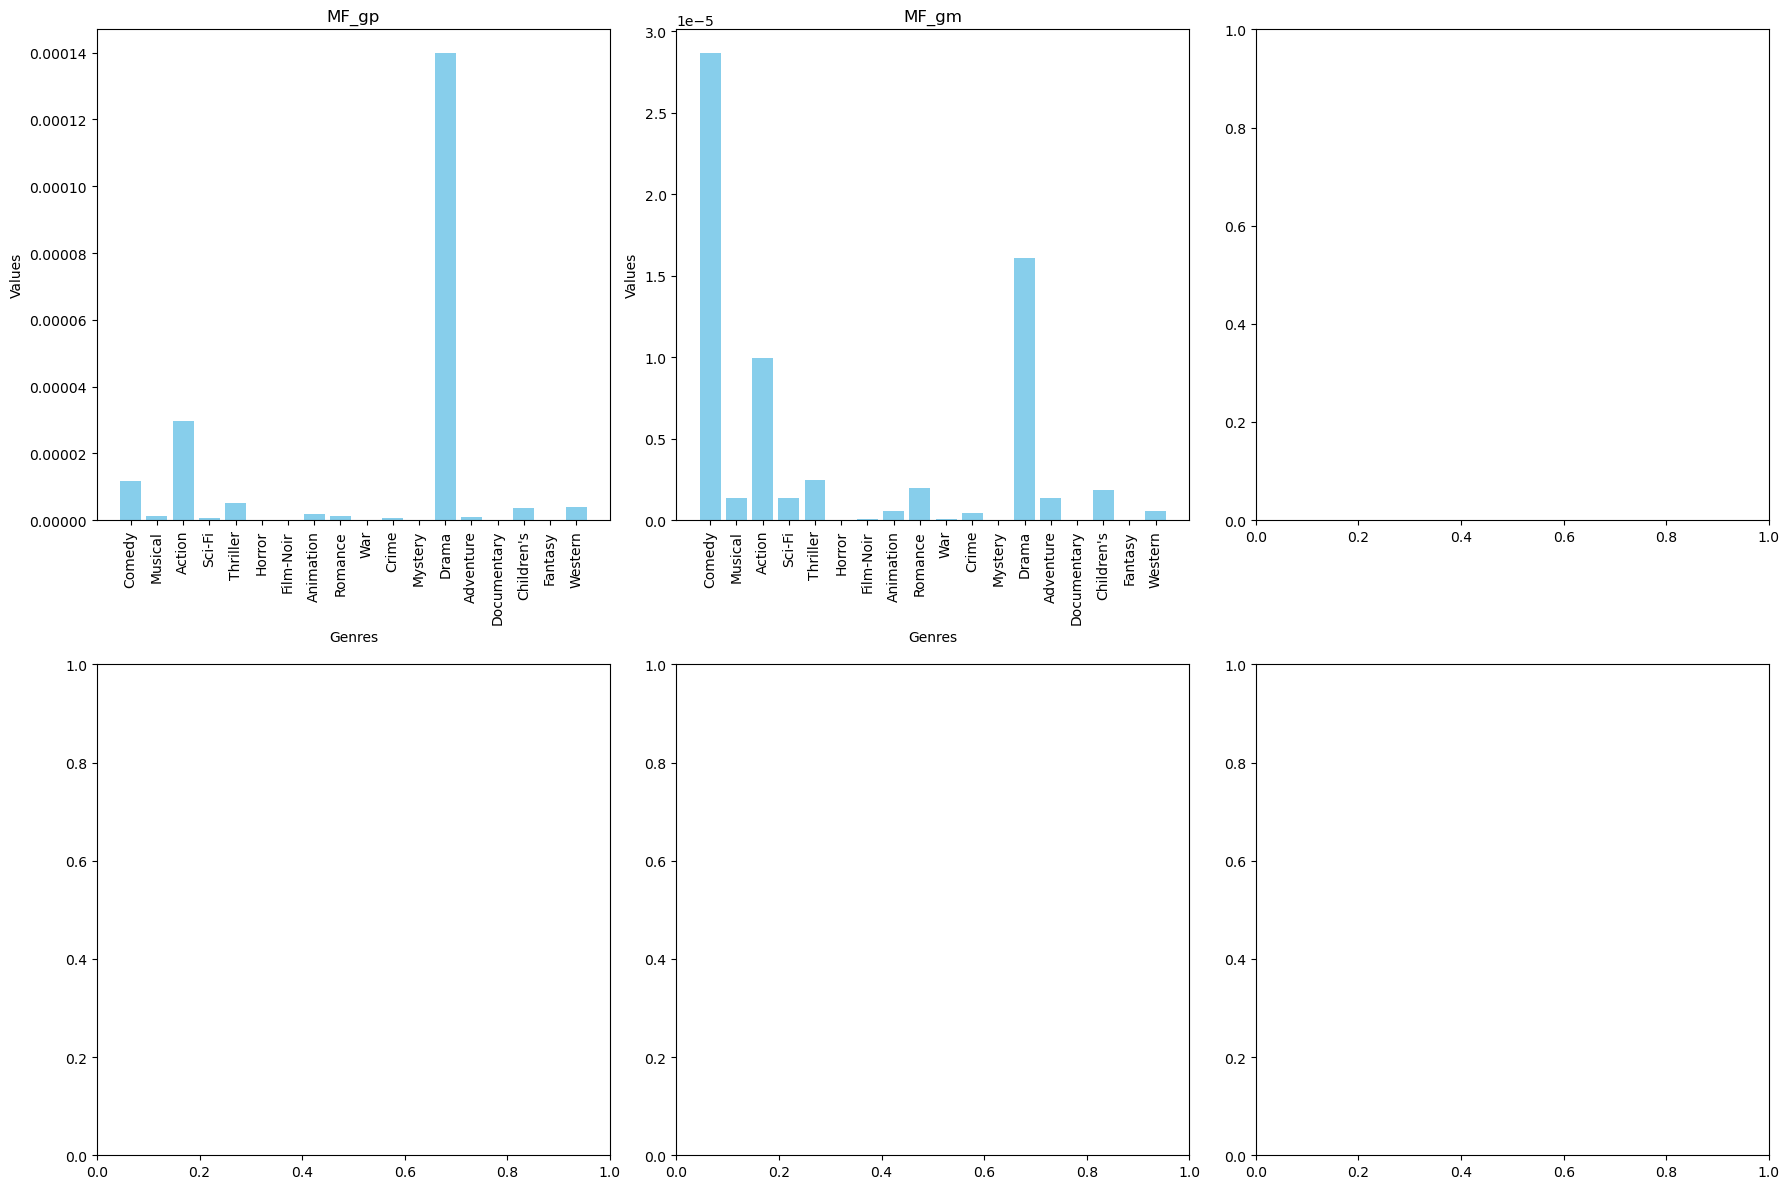

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [102]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)
    
    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if (movies.at[index,genre]==1):
                movies.at[index, genre] = weight_per_genre

In [ ]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd,movies, how="inner",on="itemID")
mergde_pd[:5]

,userID,itemID,Rating,Timestamp,movieID,genres,Comedy,Sci-Fi,Animation,Adventure,...,Film-Noir,Horror,Drama,Musical,Children's,Fantasy,War,Thriller,Crime,Western
0,0,0,5,978300760,1193,Drama,0.000000,0.0,0.000000,0.0,...,0.0,0.0,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,0,1,3,978302109,661,Animation|Children's|Musical,0.000000,0.0,0.333333,0.0,...,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,0.0
2,0,2,3,978301968,914,Musical|Romance,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.500000,0.000000,0.0,0.0,0.0,0.0,0.0
3,0,3,4,978300275,3408,Drama,0.000000,0.0,0.000000,0.0,...,0.0,0.0,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,0,4,5,978824291,2355,Animation|Children's|Comedy,0.333333,0.0,0.333333,0.0,...,0.0,0.0,0.0,0.000000,0.333333,0.0,0.0,0.0,0.0,0.0


In [ ]:
user_genre_means = mergde_pd.groupby('userID')[unique_genres].mean()
user_genre_means


,Comedy,Musical,Action,Sci-Fi,Thriller,Horror,Film-Noir,Animation,Romance,War,Crime,Mystery,Drama,Adventure,Documentary,Children's,Fantasy,Western
userID,,,,,,,,,,,,,,,,,,
0,0.129560,0.109119,0.028302,0.018868,0.031447,0.000000,0.000000,0.132704,0.053459,0.015723,0.012579,0.000000,0.292453,0.024214,0.000000,0.132704,0.018868,0.000000
1,0.098191,0.000000,0.169121,0.043798,0.093669,0.006460,0.001938,0.000000,0.069380,0.040568,0.034884,0.006460,0.382041,0.043798,0.000000,0.000000,0.001938,0.007752
2,0.355229,0.003922,0.153268,0.033987,0.040850,0.016340,0.000000,0.016993,0.029085,0.007843,0.000000,0.006536,0.075817,0.176144,0.000000,0.016993,0.011438,0.055556
3,0.000000,0.000000,0.376190,0.126190,0.067460,0.051587,0.000000,0.000000,0.025397,0.034921,0.015873,0.000000,0.132540,0.086508,0.000000,0.011905,0.023810,0.047619
4,0.188131,0.005471,0.069024,0.031566,0.092172,0.029461,0.005471,0.008418,0.072811,0.012626,0.047138,0.015152,0.360690,0.015152,0.030303,0.011364,0.000000,0.005051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6035,0.182395,0.015184,0.067661,0.079955,0.081494,0.047372,0.008071,0.016160,0.060867,0.018656,0.025619,0.016273,0.293056,0.035473,0.010698,0.024794,0.006794,0.009478
6036,0.167492,0.007838,0.047607,0.078960,0.176568,0.019802,0.017327,0.001650,0.041419,0.032756,0.034653,0.023102,0.311056,0.012541,0.002475,0.009488,0.004950,0.010314
6037,0.366667,0.000000,0.035000,0.010000,0.000000,0.050000,0.000000,0.075000,0.110000,0.060000,0.000000,0.000000,0.258333,0.010000,0.000000,0.025000,0.000000,0.000000


In [ ]:
users

,userID,Gender
0,0,1
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
6035,6035,1
6036,6036,1
6037,6037,1
6038,6038,1


In [ ]:
useer= pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby('Gender')[unique_genres].mean()
user_genre_gender


,Comedy,Musical,Action,Sci-Fi,Thriller,Horror,Film-Noir,Animation,Romance,War,Crime,Mystery,Drama,Adventure,Documentary,Children's,Fantasy,Western
Gender,,,,,,,,,,,,,,,,,,
0,0.203637,0.013770,0.112976,0.070855,0.091484,0.044618,0.009522,0.01604,0.049907,0.031133,0.032804,0.015763,0.206559,0.047763,0.006794,0.022604,0.011497,0.012273
1,0.228915,0.023042,0.069847,0.041291,0.077945,0.032999,0.008491,0.01950,0.090118,0.024085,0.026827,0.016482,0.247989,0.036050,0.007716,0.031251,0.011143,0.006308


In [80]:
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,5,978300760
1,0,1,3,978302109
2,0,2,3,978301968
3,0,3,4,978300275
4,0,4,5,978824291
...,...,...,...,...
999606,6039,772,1,956716541
999607,6039,1106,5,956704887
999608,6039,365,5,956704746
999609,6039,152,4,956715648


In [115]:
# inter_movies
z= inter_movies[["userID","itemID","Gender"]]
mergz= pd.merge(z,movies, on="itemID",how="left")
mergz
user_genre_gender = mergz.groupby('Gender')[unique_genres].mean()
user_genre_gender


,Drama,Children's,Action,War,Documentary,Animation,Comedy,Sci-Fi,Romance,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror
Gender,,,,,,,,,,,,,,,,,,
0,0.128797,0.025067,0.155463,0.025427,0.011284,0.016803,0.134711,0.094746,0.033451,0.009417,0.017207,0.034410,0.128323,0.065184,0.013813,0.020436,0.012184,0.073275
1,0.325799,0.048793,0.000383,0.000110,0.010828,0.027534,0.336074,0.024512,0.112172,0.033176,0.008371,0.018635,0.000429,0.022856,0.013784,0.010287,0.006089,0.000168


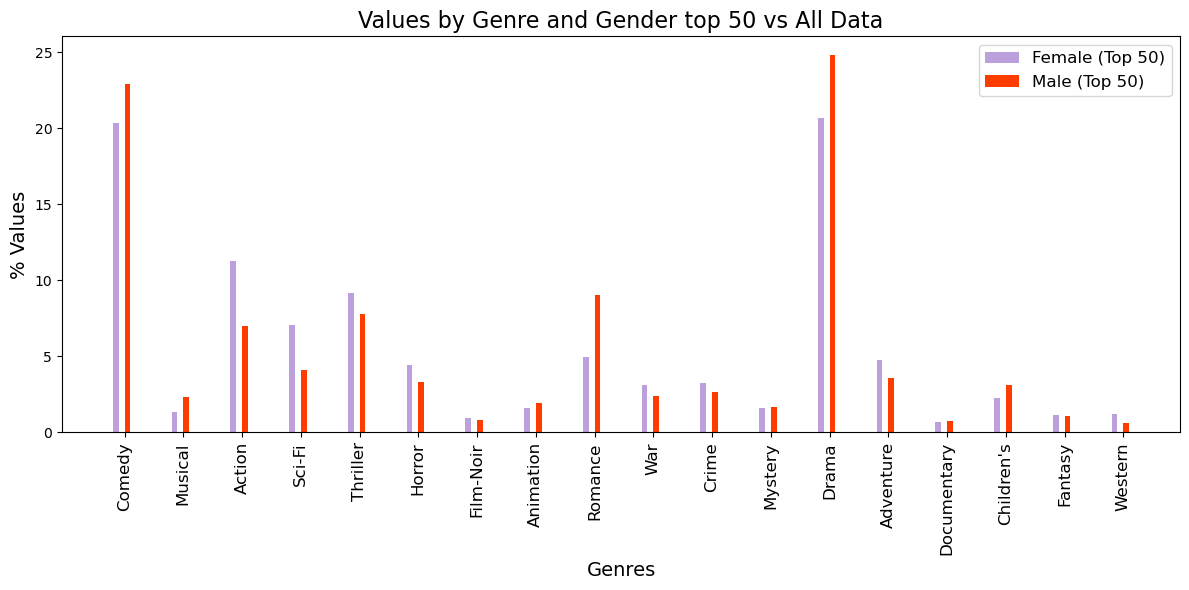

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


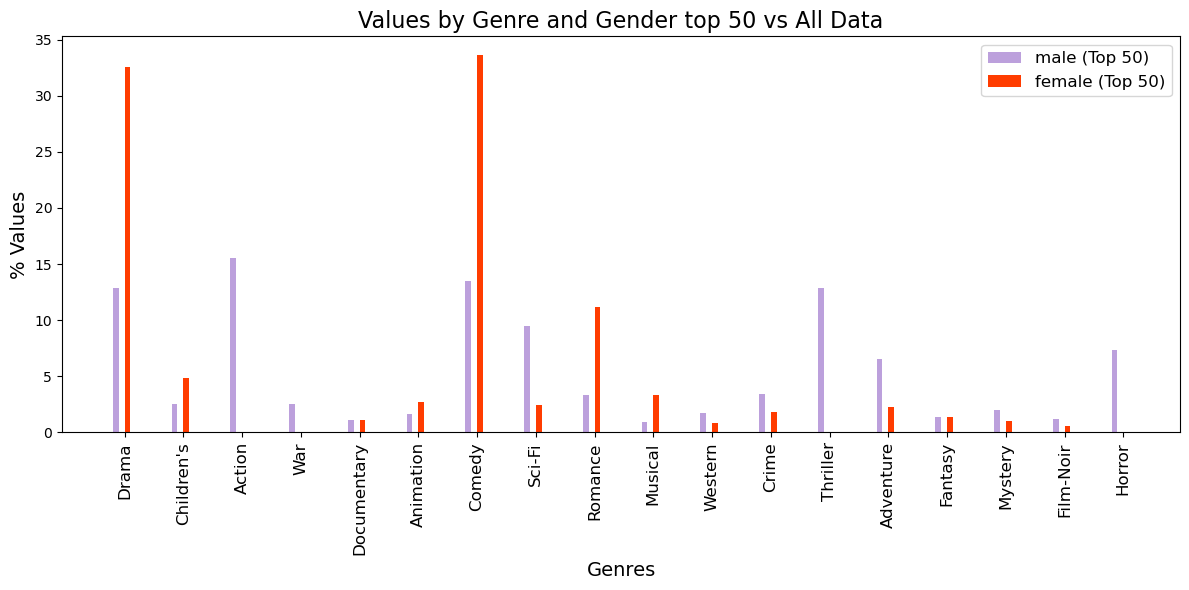

In [116]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='male (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='female (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [120]:
# inter_movies["itemID"].nunique()

3416

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[0].shape[0] + 1).repeat(reco_matrix[0].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[0].flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


,Comedy,Musical,Action,Sci-Fi,Thriller,Horror,Film-Noir,Animation,Romance,War,Crime,Mystery,Drama,Adventure,Documentary,Children's,Fantasy,Western
Gender,,,,,,,,,,,,,,,,,,
0,0.193773,0.051764,0.119993,0.043264,0.073814,0.01,0.006667,0.055268,0.051667,0.006667,0.034932,0.0,0.220162,0.039931,0.0,0.048601,0.0,0.043498
1,0.193782,0.051819,0.119934,0.043272,0.073723,0.01,0.006667,0.055322,0.051667,0.006667,0.034942,0.0,0.220100,0.039939,0.0,0.048655,0.0,0.043513


In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame


,Comedy,Musical,Action,Sci-Fi,Thriller,Horror,Film-Noir,Animation,Romance,War,Crime,Mystery,Drama,Adventure,Documentary,Children's,Fantasy,Western
Gender,,,,,,,,,,,,,,,,,,
0,0.194886,0.055998,0.127428,0.041921,0.075072,0.01,0.006667,0.055028,0.051667,0.006665,0.033588,0.0,0.210647,0.038583,0.0,0.048361,0.0,0.043487
1,0.194945,0.056069,0.127436,0.041890,0.075048,0.01,0.006667,0.055053,0.051667,0.006663,0.033557,0.0,0.210546,0.038545,0.0,0.048386,0.0,0.043528


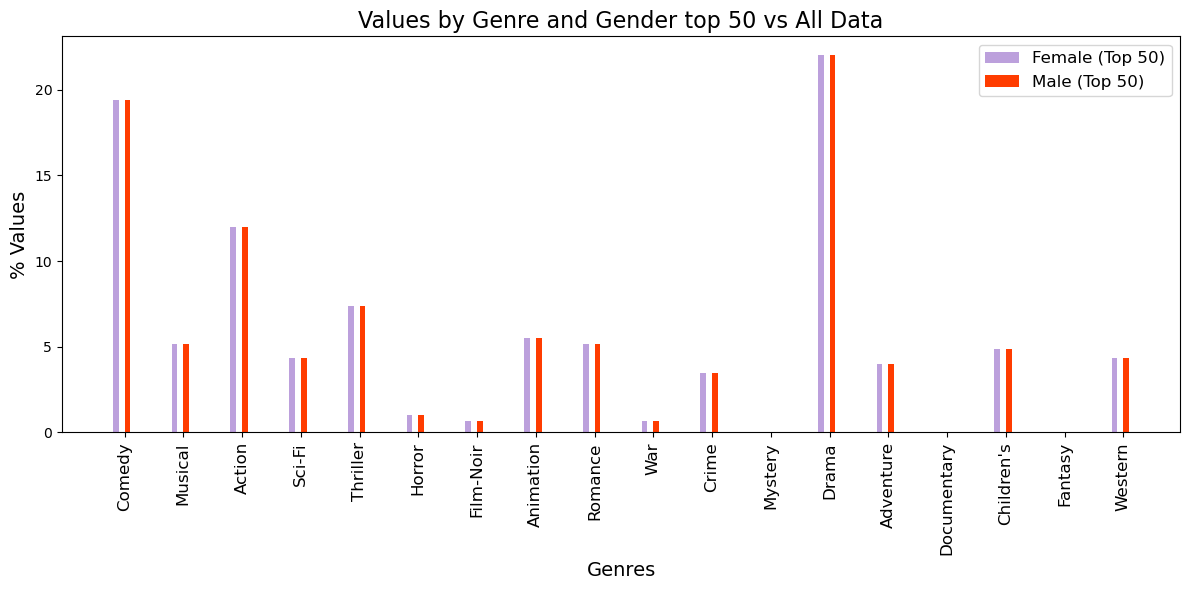

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


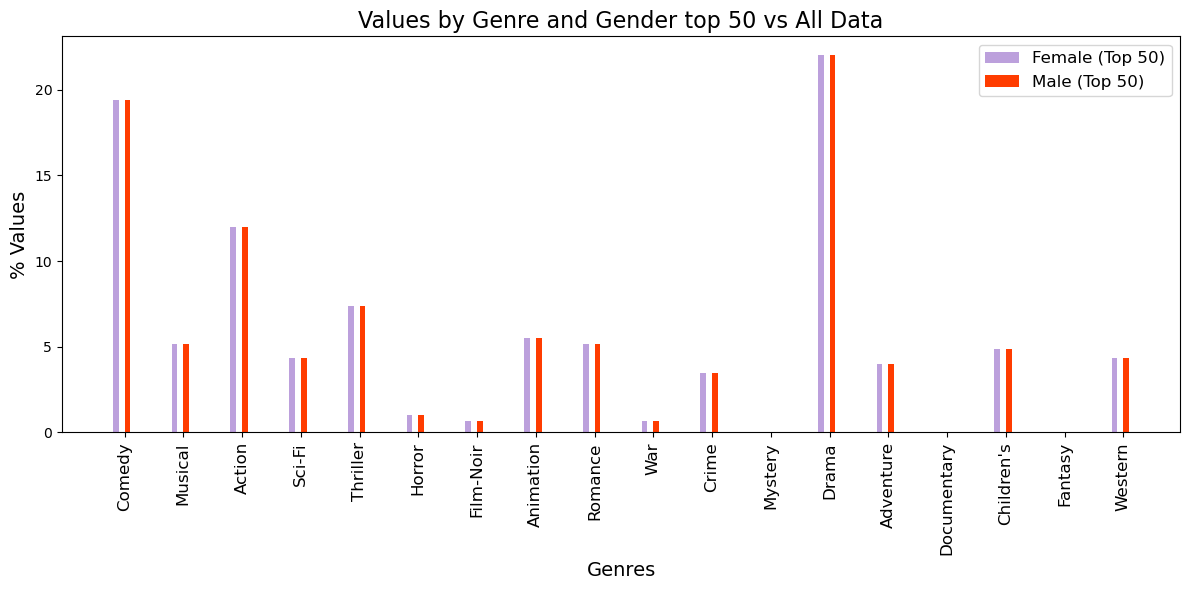

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix.shape[0] + 1).repeat(reco_matrix.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix.flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


,Comedy,Sci-Fi,Animation,Adventure,Documentary,Mystery,Romance,Action,Film-Noir,Horror,Drama,Musical,Children's,Fantasy,War,Thriller,Crime,Western
Gender,,,,,,,,,,,,,,,,,,
0,0.216307,0.041355,0.028848,0.024509,0.004355,0.014292,0.055443,0.051728,0.002722,0.029869,0.352402,0.044639,0.030163,0.008037,0.010180,0.049310,0.011159,0.024683
1,0.217560,0.041353,0.028322,0.023816,0.004602,0.014469,0.055884,0.051610,0.002857,0.029601,0.354431,0.043354,0.029623,0.007807,0.009886,0.049617,0.011101,0.024106


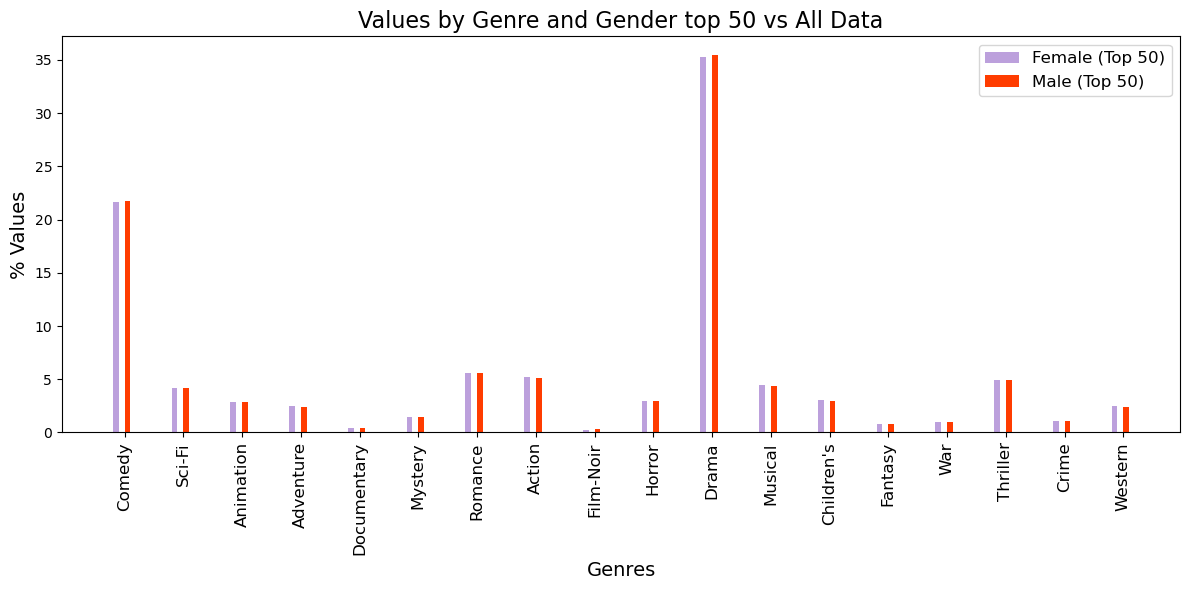

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [140]:
inter_movies

,userID,itemID,Rating,Timestamp,movieID,genres,Drama,Children's,Action,War,...,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror,Gender
0,0,0,5,978300760,1193,Drama,1.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0,1,3,978302109,661,Animation|Children's|Musical,0.000000,0.333333,0.0,0.000000,...,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0,2,3,978301968,914,Musical|Romance,0.000000,0.000000,0.0,0.000000,...,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0,3,4,978300275,3408,Drama,1.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0,4,5,978824291,2355,Animation|Children's|Comedy,0.000000,0.333333,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595367,6039,183,2,956715648,1079,Comedy,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
595368,6039,2506,4,956704746,549,Documentary,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
595369,6039,754,3,956716374,2021,Fantasy|Sci-Fi,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0
595370,6039,336,4,956704996,1089,Crime|Thriller,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0


In [141]:
inter_movies.to_csv('biased_movie_lens.csv')